In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muqaddasejaz/perfume-e-commerce-dataset/ebay_womens_perfume_data.csv
/kaggle/input/datasets/muqaddasejaz/perfume-e-commerce-dataset/ebay_mens_perfume_data.csv


# Men vs Womens Perfume

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

In [3]:
women_df = pd.read_csv("/kaggle/input/datasets/muqaddasejaz/perfume-e-commerce-dataset/ebay_womens_perfume_data.csv")
men_df = pd.read_csv("/kaggle/input/datasets/muqaddasejaz/perfume-e-commerce-dataset/ebay_mens_perfume_data.csv")

print("\nData have been loaded completely!")


Data have been loaded completely!


# Preview of the Dataset

In [4]:
print(women_df.head(5))
print("----------------------------------")
print(men_df.head(5))

              brand                                              title  \
0  Carolina Herrera  Good Girl by Carolina Herrera 2.7 oz Eau De Pa...   
1          As Shown  Parfums de Marly Delina La Rosee Eau de Parfum...   
2             PRADA  PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...   
3           As Show  J'adore Parfum D'eau by Christian 3.4 oz EDP F...   
4           Khadlaj  Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...   

            type  price priceWithCurrency  available  \
0  Eau de Parfum  43.99      US $43.99/ea        2.0   
1  Eau de Parfum  79.99         US $79.99        5.0   
2  Eau de Parfum  59.99         US $59.99       10.0   
3  Eau de Parfum  59.99      US $59.99/ea       10.0   
4  Eau de Parfum  29.99      US $29.99/ea       10.0   

                      availableText   sold                lastUpdated  \
0            2 available / 393 sold  393.0  May 23, 2024 10:43:50 PDT   
1             5 available / 40 sold   40.0  May 24, 2024 00:15:48 PDT   

In [5]:
print("Women:\n", women_df.dtypes)
print()
print("Men:\n", men_df.dtypes)

Women:
 brand                 object
title                 object
type                  object
price                float64
priceWithCurrency     object
available            float64
availableText         object
sold                 float64
lastUpdated           object
itemLocation          object
dtype: object

Men:
 brand                 object
title                 object
type                  object
price                float64
priceWithCurrency     object
available            float64
availableText         object
sold                 float64
lastUpdated           object
itemLocation          object
dtype: object


In [6]:
print("Women:", women_df.shape)
print("Men:", men_df.shape)

Women: (1000, 10)
Men: (1000, 10)


In [7]:
print(women_df.describe(include = 'all').T)

                    count unique  \
brand                 999    247   
title                1000    975   
type                  998     71   
price              1000.0    NaN   
priceWithCurrency    1000    655   
available           869.0    NaN   
availableText         992    746   
sold                984.0    NaN   
lastUpdated           927    911   
itemLocation         1000    299   

                                                                 top freq  \
brand                                                        Lancôme   37   
title              Idole by Lancome Eau de Parfum EDP Perfume for...    4   
type                                                   Eau de Parfum  562   
price                                                            NaN  NaN   
priceWithCurrency                                       US $49.99/ea   20   
available                                                        NaN  NaN   
availableText                        More than 10 available / 3 

In [8]:
print(men_df.describe(include = 'all').T)

                    count unique  \
brand                 999    246   
title                1000    966   
type                  997     63   
price              1000.0    NaN   
priceWithCurrency    1000    685   
available           889.0    NaN   
availableText         997    758   
sold                994.0    NaN   
lastUpdated           947    933   
itemLocation         1000    276   

                                                                 top freq  \
brand                                                 Giorgio Armani   60   
title              YSL Yves Saint Laurent Y Eau de Perfume Spray ...    4   
type                                                 Eau de Toilette  444   
price                                                            NaN  NaN   
priceWithCurrency                                       US $29.99/ea   21   
available                                                        NaN  NaN   
availableText                       More than 10 available / 16 

In [9]:
print(women_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               998 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          869 non-null    float64
 6   availableText      992 non-null    object 
 7   sold               984 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB
None


In [10]:
print(men_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB
None


# Missing value check

In [11]:
print(women_df.isnull().sum())

brand                  1
title                  0
type                   2
price                  0
priceWithCurrency      0
available            131
availableText          8
sold                  16
lastUpdated           73
itemLocation           0
dtype: int64


In [12]:
print(men_df.isnull().sum())

brand                  1
title                  0
type                   3
price                  0
priceWithCurrency      0
available            111
availableText          3
sold                   6
lastUpdated           53
itemLocation           0
dtype: int64


# Visualize of missing values

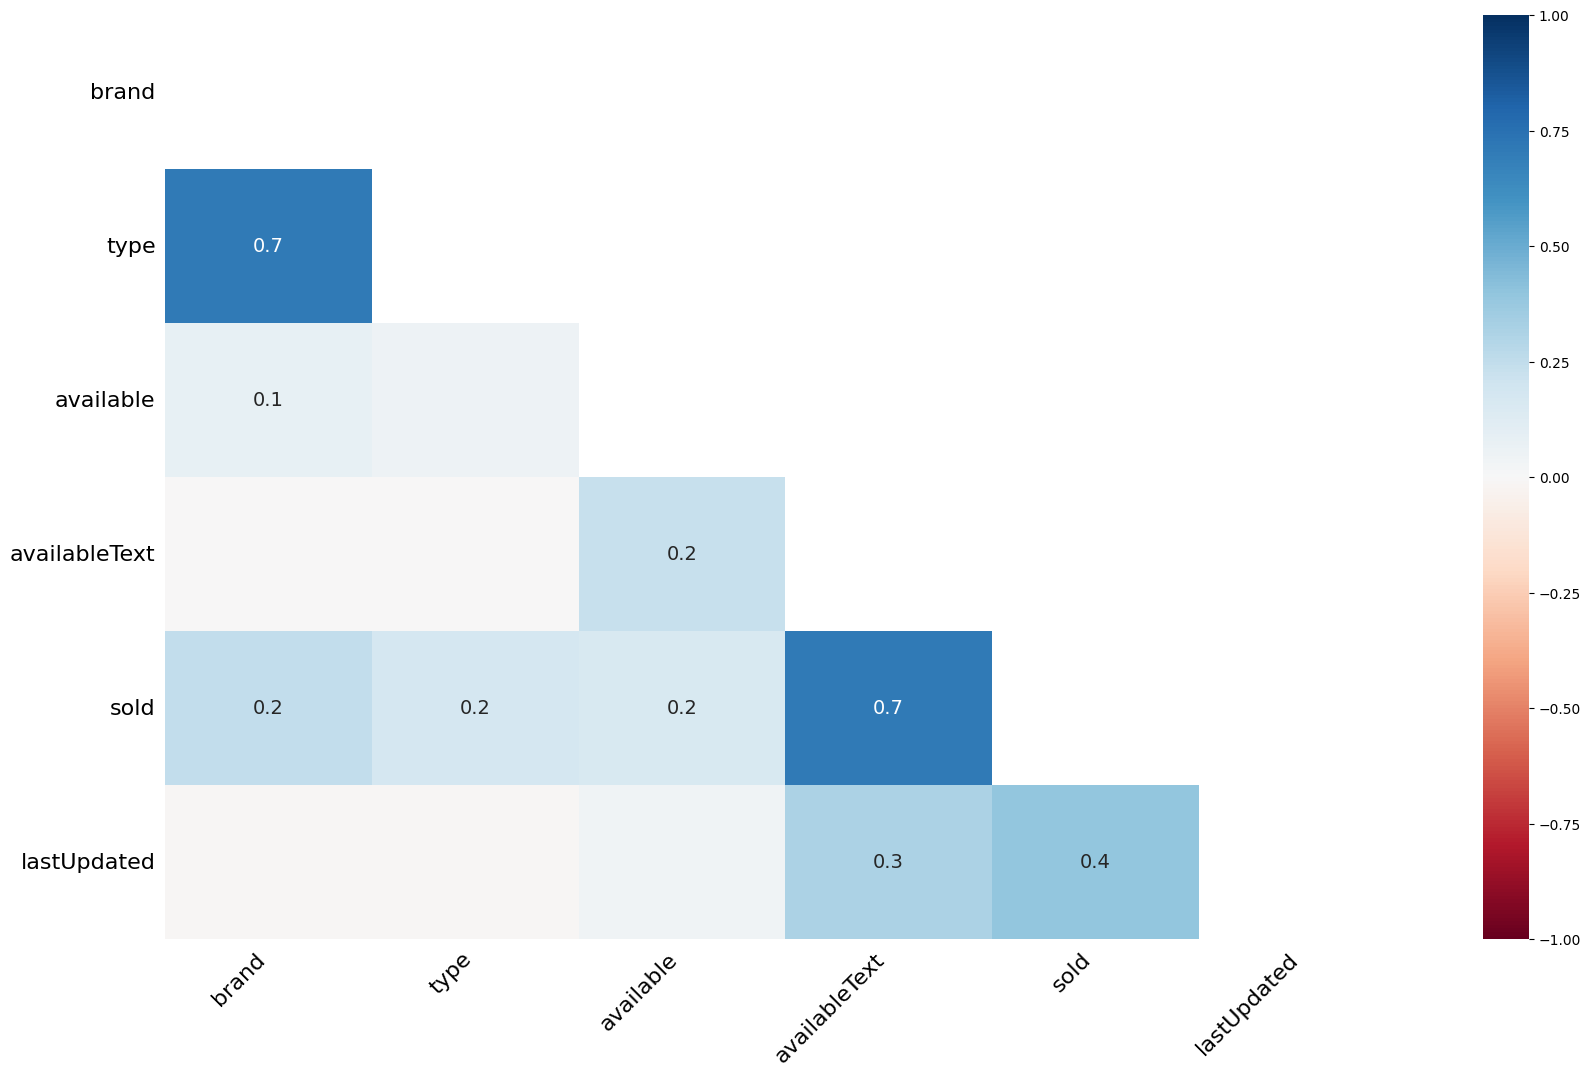

In [13]:
import missingno as msno
msno.heatmap(women_df)
plt.show()

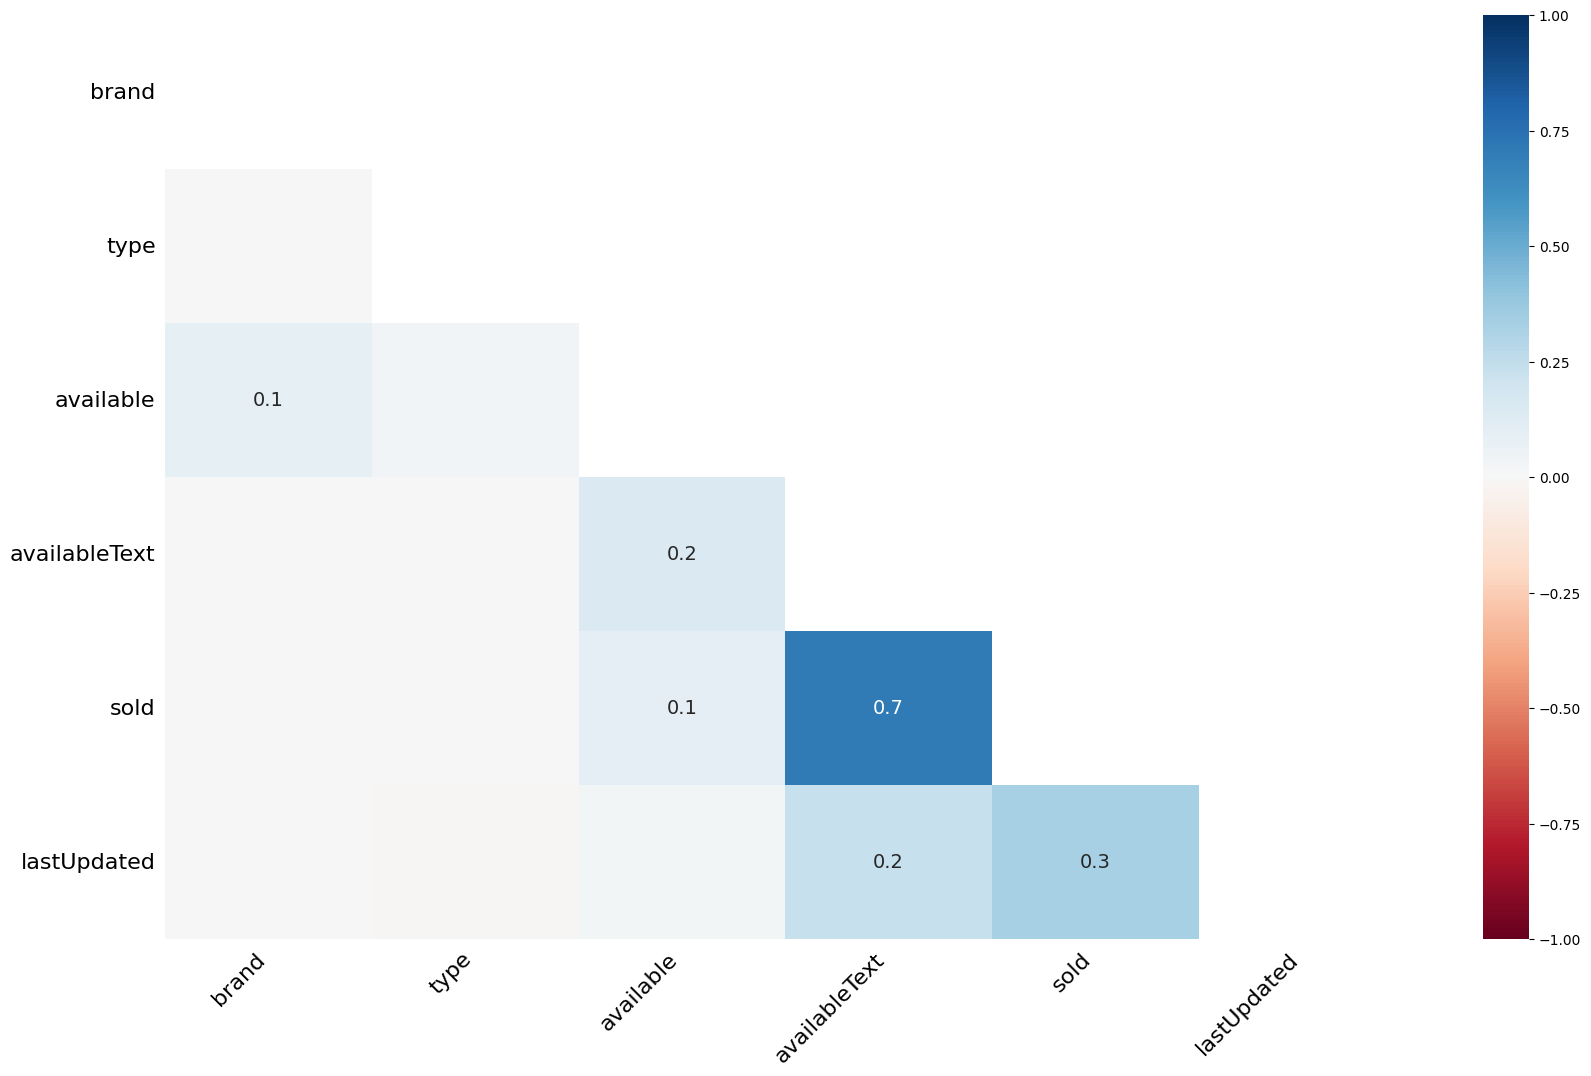

In [14]:
msno.heatmap(men_df)
plt.show()

In [15]:
num_cols = women_df.select_dtypes(include = ['int64','float64']).columns.tolist()
print("Numeric values of Women:\n", num_cols)

print()

num_cols = men_df.select_dtypes(include = ['int64','float64']).columns.tolist()
print("Numeric values of Men:\n", num_cols)


Numeric values of Women:
 ['price', 'available', 'sold']

Numeric values of Men:
 ['price', 'available', 'sold']


In [16]:
cat_cols = women_df.select_dtypes(include = ['object']).columns.tolist()
print("Categories values of Women:\n", cat_cols)

print()

cat_cols = men_df.select_dtypes(include = ['object']).columns.tolist()
print("Categories values of Men:\n", cat_cols)


Categories values of Women:
 ['brand', 'title', 'type', 'priceWithCurrency', 'availableText', 'lastUpdated', 'itemLocation']

Categories values of Men:
 ['brand', 'title', 'type', 'priceWithCurrency', 'availableText', 'lastUpdated', 'itemLocation']


In [17]:
women_df.duplicated().sum()
men_df.duplicated().sum()

np.int64(0)

* **I have completed the missing values check and a few other steps. Now, I need all the plots for the numeric values.**

# Visualization of Numeric Variables

* After handling missing values and performing initial preprocessing, we will now visualize the distributions and relationships of numeric columns (price, available, sold) using Histograms, Boxplots, and Correlation Heatmaps."

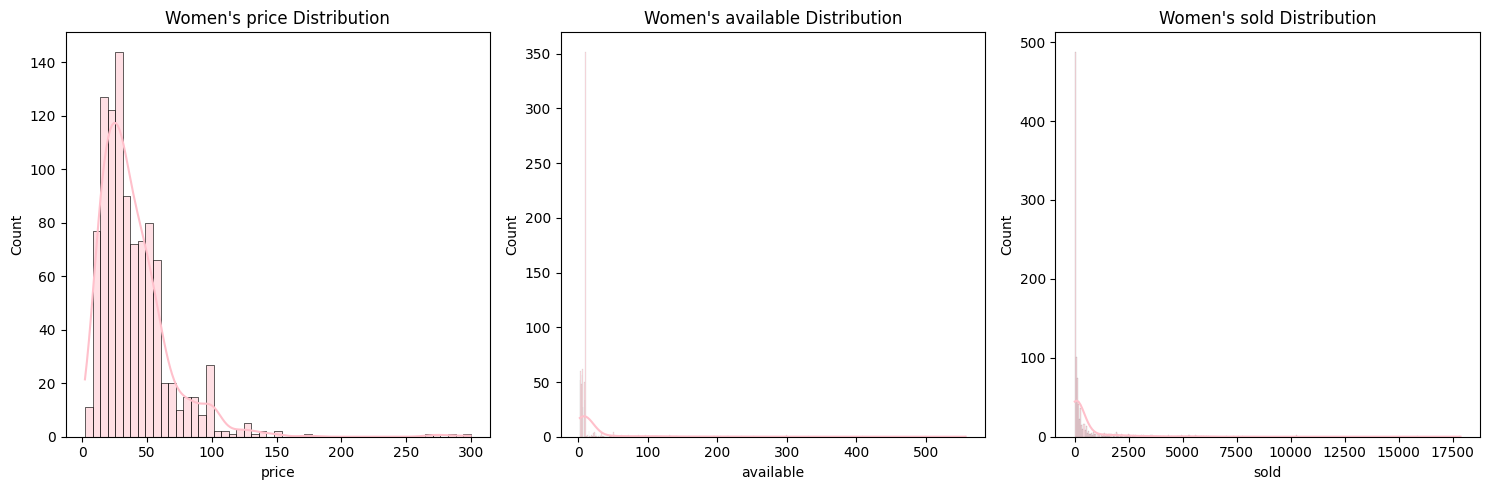

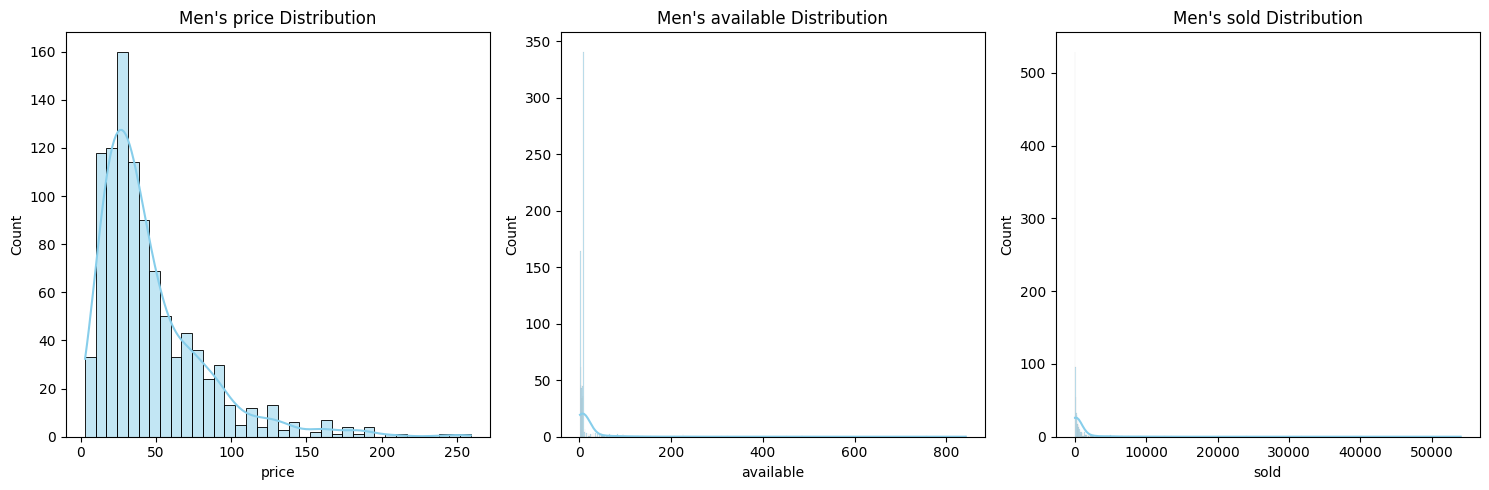

In [18]:
# List of numeric columns
cols_to_plot = ['price', 'available', 'sold']

# Plotting Distribution for Women's Perfume
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot):
    plt.subplot(1, 3, i+1)
    sns.histplot(women_df[col], kde=True, color='pink')
    plt.title(f'Women\'s {col} Distribution')
plt.tight_layout()
plt.show()

# Plotting Distribution for Men's Perfume
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot):
    plt.subplot(1, 3, i+1)
    sns.histplot(men_df[col], kde=True, color='skyblue')
    plt.title(f'Men\'s {col} Distribution')
plt.tight_layout()
plt.show()

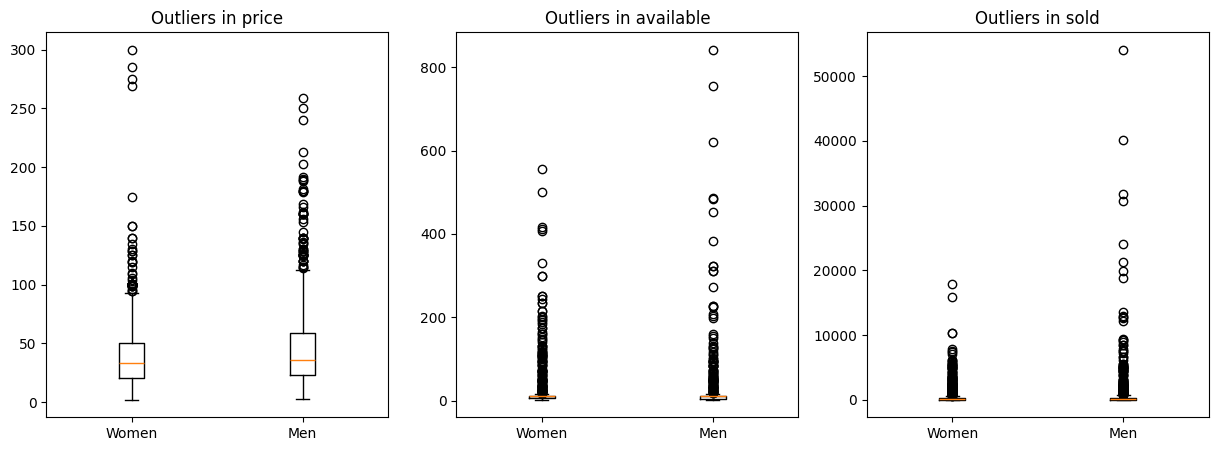

In [19]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot):
    plt.subplot(1, 3, i+1)
    # Dono datasets ko compare karne ke liye side-by-side boxplot
    data_to_plot = [women_df[col].dropna(), men_df[col].dropna()]
    plt.boxplot(data_to_plot, labels=['Women', 'Men'])
    plt.title(f'Outliers in {col}')
plt.show()

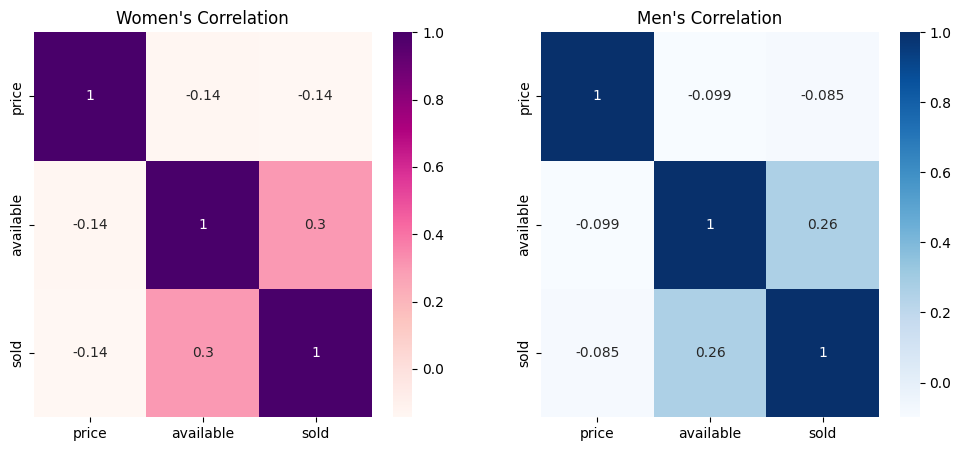

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(women_df[cols_to_plot].corr(), annot=True, cmap='RdPu')
plt.title('Women\'s Correlation')

plt.subplot(1, 2, 2)
sns.heatmap(men_df[cols_to_plot].corr(), annot=True, cmap='Blues')
plt.title('Men\'s Correlation')

plt.show()

* Histograms: To check the Distribution (Spread of data).

* Boxplots: To identify Outliers (Extreme values).

* Heatmaps: To find the Correlation (Relationship between variables).

# Visualization of Categorical Variables

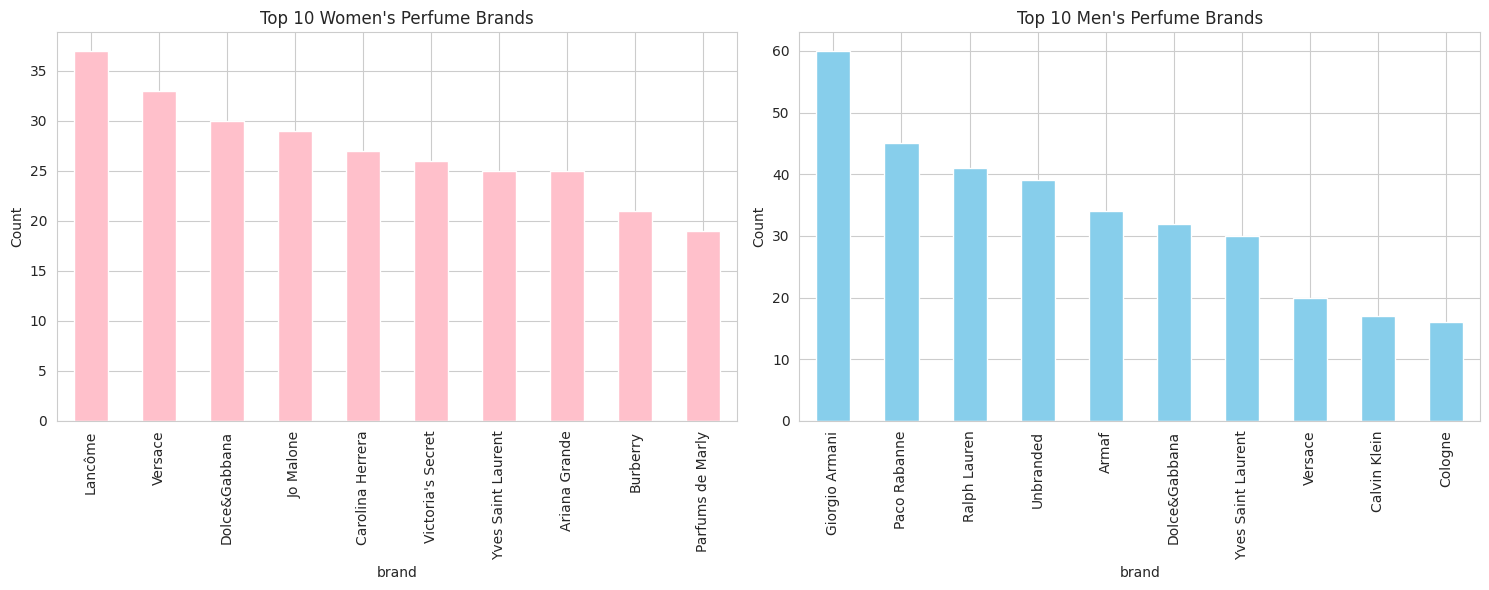

In [21]:
# Setting the style
sns.set_style("whitegrid")

# Plotting Top 10 Brands for Women
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
women_df['brand'].value_counts().head(10).plot(kind='bar', color='pink')
plt.title('Top 10 Women\'s Perfume Brands')
plt.ylabel('Count')

# Plotting Top 10 Brands for Men
plt.subplot(1, 2, 2)
men_df['brand'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Men\'s Perfume Brands')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

* Brand Dominance: The bar charts show the most frequently listed brands on eBay. This helps identify which manufacturers have the highest resale or inventory presence in the e-commerce market.

* Market Variety: By comparing the Women's and Men's charts, we can see if certain brands (like Lancôme or Giorgio Armani) dominate one gender category more than the other.

* Product Type Preference: Analysis of the type column usually shows a higher frequency of Eau de Parfum (EDP) for women and Eau de Toilette (EDT) for men, reflecting standard industry trends.

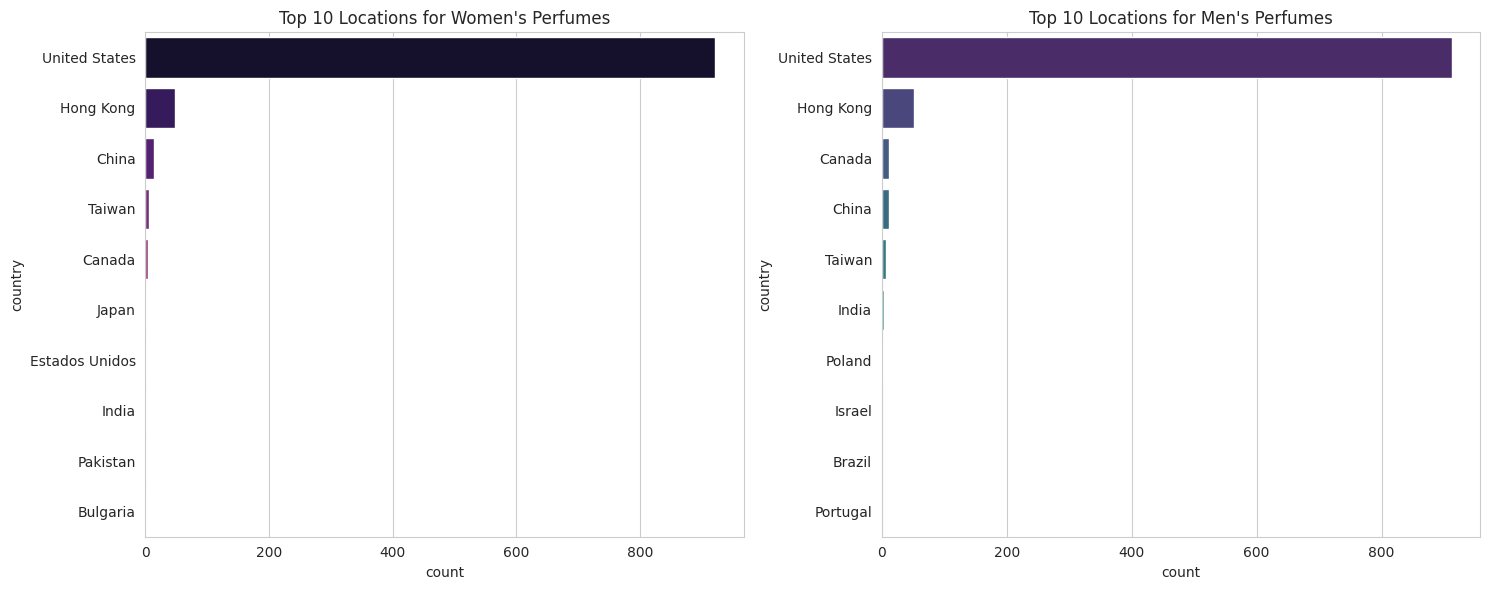

In [22]:
# Function to extract the last part of the location (usually the Country or State)
def extract_country(location):
    if pd.isna(location):
        return 'Unknown'
    return location.split(',')[-1].strip()

# Applying extraction
women_df['country'] = women_df['itemLocation'].apply(extract_country)
men_df['country'] = men_df['itemLocation'].apply(extract_country)

# Plotting Top Locations
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=women_df, y='country', order=women_df['country'].value_counts().index[:10], palette='magma')
plt.title('Top 10 Locations for Women\'s Perfumes')

plt.subplot(1, 2, 2)
sns.countplot(data=men_df, y='country', order=men_df['country'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Locations for Men\'s Perfumes')

plt.tight_layout()
plt.show()

* Geographic Concentration: The majority of the listings are concentrated in the United States, followed by international hubs like Hong Kong and Canada. This suggests that these regions are major distribution points for eBay perfume sellers.

* Shipping Hubs: Cities like Dallas, Texas and New Jersey often appear frequently (if you look at the full string), indicating large warehouse operations for e-commerce fragrances in those areas.

* Market Reach: While the platform is global, the heavy concentration in specific US states shows where the most competitive pricing and inventory are likely located.

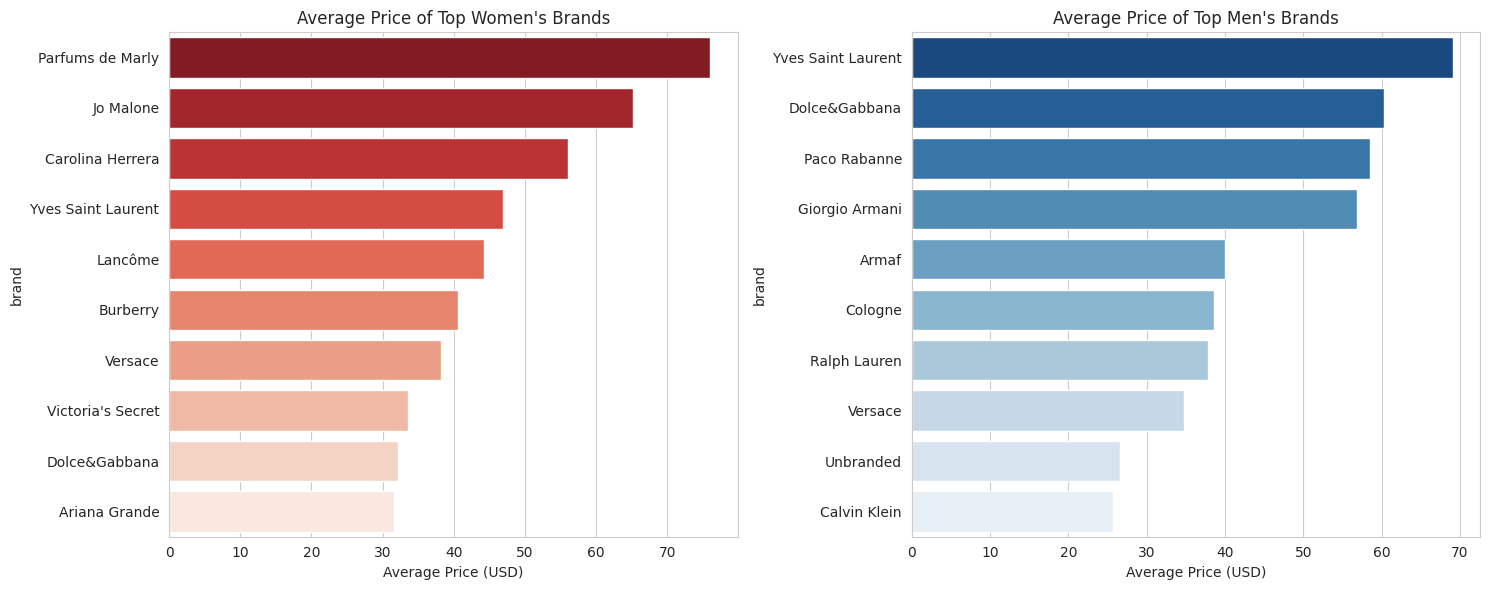

In [23]:
# Calculating top brands by frequency first
top_women_brands = women_df['brand'].value_counts().head(10).index
top_men_brands = men_df['brand'].value_counts().head(10).index

# Filtering data for these brands and calculating mean price
women_avg_price = women_df[women_df['brand'].isin(top_women_brands)].groupby('brand')['price'].mean().sort_values(ascending=False)
men_avg_price = men_df[men_df['brand'].isin(top_men_brands)].groupby('brand')['price'].mean().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=women_avg_price.values, y=women_avg_price.index, palette='Reds_r')
plt.title('Average Price of Top Women\'s Brands')
plt.xlabel('Average Price (USD)')

plt.subplot(1, 2, 2)
sns.barplot(x=men_avg_price.values, y=men_avg_price.index, palette='Blues_r')
plt.title('Average Price of Top Men\'s Brands')
plt.xlabel('Average Price (USD)')

plt.tight_layout()
plt.show()

1. Premium Pricing: This visualization identifies which of the popular brands command a premium price. For example, brands like Chanel or Dior typically show a higher average price compared to mass-market brands.

2. Value for Money Brands: Some brands might have a high "count" in the market but a lower "average price," indicating they are the budget-friendly favorites among eBay buyers.

3. Price Disparity: By comparing the two charts, we can see if Men's premium fragrances are priced higher on average than Women's premium fragrances for the same brand.

# **Title Keyword Analysis (Word Cloud)**

* In this step, we visualize the most frequent words found in the perfume titles. This helps us understand the marketing language used by sellers (e.g., "Vintage," "Luxury," "Authentic").

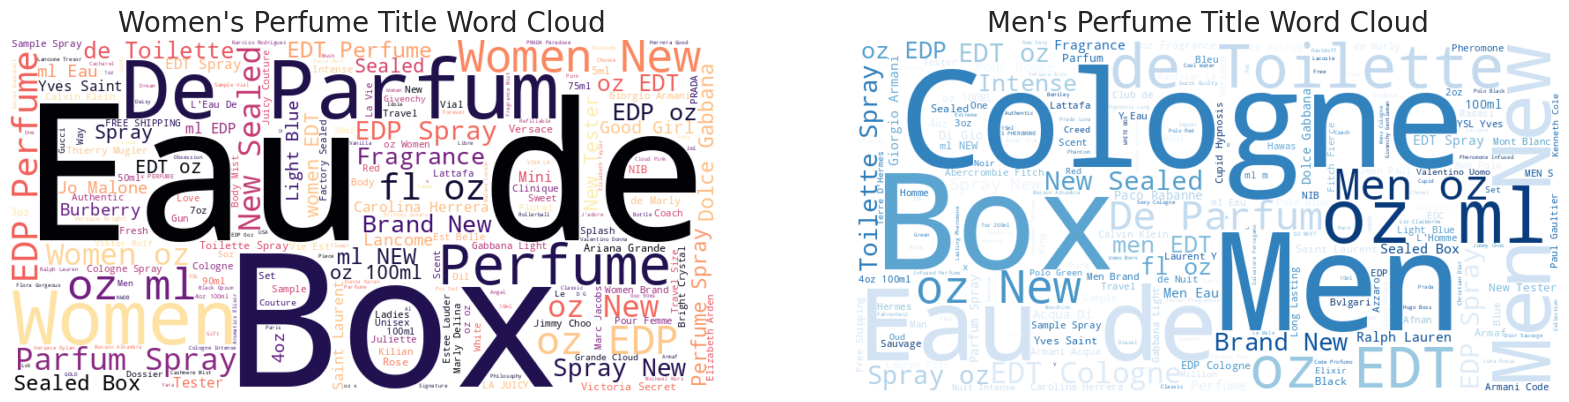

In [24]:
from wordcloud import WordCloud

# Combine all titles into a single string for both datasets
women_titles = " ".join(title for title in women_df.title.astype(str))
men_titles = " ".join(title for title in men_df.title.astype(str))

# Generate Word Clouds
wc_women = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(women_titles)
wc_men = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(men_titles)

# Plotting
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(wc_women, interpolation='bilinear')
plt.title('Women\'s Perfume Title Word Cloud', fontsize=20)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_men, interpolation='bilinear')
plt.title('Men\'s Perfume Title Word Cloud', fontsize=20)
plt.axis('off')

plt.show()

* **Key Insights**

* Selling Points: Notice how words like "Spray," "Eau de Parfum," and "New" are large, meaning they are used in almost every listing to provide essential product details.

* Marketing Keywords: Look for words like "Authentic," "Classic," or "Rare." These are "power words" sellers use to justify prices or attract collectors.

* Size Matters: Frequently mentioned sizes (like "3.4 oz" or "100ml") often appear prominently, showing the standard bottle sizes available in the market.

# **Conclusion of EDA**

* Missing Data (Handling null values).

* Numeric Data (Price, Availability, and Sales distributions).

* Categorical Data (Top Brands and Types).

* Geographic Data (Seller locations).

* Pricing Strategy (Average brand prices).

* Textual Data (Word Cloud of titles).

# **Machine Learning**

* For this dataset, our goal will likely be Price Prediction (Regression). We want to see if the model can learn to predict a perfume's price based on its brand, type, and sales data.

* Here are the steps we will follow:

1. Feature Selection: Choosing which columns help predict price.

2. Data Encoding: Converting text (like 'brand') into numbers.

3. Model Training: Training a model (like Random Forest).

4. Evaluation: Checking how accurate the model is.

 **Preprocessing for ML**

* We need to handle the categorical text and fill any remaining small NaNs in the numeric columns so the model doesn't crash.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Choosing features for the model
features = ['brand', 'type', 'available', 'sold']
target = 'price'

# Making a copy to keep original data safe
ml_df = women_df[features + [target]].copy()

# Filling minor missing values for ML
ml_df['brand'] = ml_df['brand'].fillna('Unknown')
ml_df['type'] = ml_df['type'].fillna('Unknown')
ml_df['available'] = ml_df['available'].fillna(ml_df['available'].median())
ml_df['sold'] = ml_df['sold'].fillna(ml_df['sold'].median())

# Encoding Categorical Text into Numbers
le = LabelEncoder()
ml_df['brand'] = le.fit_transform(ml_df['brand'].astype(str))
ml_df['type'] = le.fit_transform(ml_df['type'].astype(str))

# Splitting Data into Training (80%) and Testing (20%)
X = ml_df[features]
y = ml_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data is ready for training!")

Data is ready for training!


 **Training the Model**

In [26]:
# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
# Predictions
y_pred = model.predict(X_test)

# Results
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Model Accuracy (R2 Score): {r2:.2f}")

Mean Absolute Error: $16.74
Model Accuracy (R2 Score): -0.20


* Label Encoding: Since machine learning models only understand numbers, we converted text columns like brand and type into numerical values using LabelEncoder.

* Train-Test Split: We split the data so the model can learn from 80% of the listings and we can test its "guessing power" on the remaining 20%.

* Mean Absolute Error (MAE): This tells us, on average, how many dollars away our price predictions are from the actual eBay price.

* R2 Score: This shows how well our features explain the variation in price. A score closer to 1.0 is perfect.

3. Visualizing Model Performance

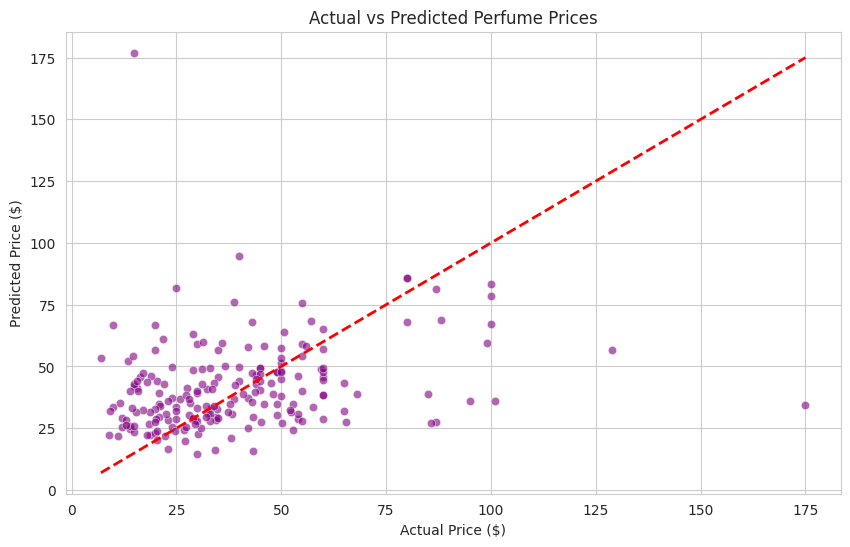

In [28]:
plt.figure(figsize=(10, 6))

# Plotting Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)

plt.title('Actual vs Predicted Perfume Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

* The Red Line: This represents "Perfect Prediction." If every dot was on this line, your model would be 100% accurate.

* The Clusters: If the dots are spread out far from the line, it means the features we used (brand, type, sold) aren't enough to explain the price. For example, a "Vintage" or "Limited Edition" keyword in the Title might be more important than the brand name itself.

* Why the R2 is low: In e-commerce, two perfumes from the same brand can have wildly different prices based on their size (ml/oz), which we haven't extracted yet.

# Advanced Model Training

* We will train all three models and see which one handles the perfume prices most accurately. 

In [29]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1. Standardizing Data (Required for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_v2)
X_test_scaled = scaler.transform(X_test_v2)

# 2. Initialize Models
models = {
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1),
    "SVM": SVR(kernel='rbf', C=100, epsilon=0.1)
}

# 3. Train and Evaluate
results = []
for name, model in models.items():
    # Use scaled data for SVM, original for Boosting models
    if name == "SVM":
        model.fit(X_train_scaled, y_train_v2)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train_v2, y_train_v2)
        preds = model.predict(X_test_v2)
    
    mae = mean_absolute_error(y_test_v2, preds)
    r2 = r2_score(y_test_v2, preds)
    results.append({"Model": name, "MAE": mae, "R2 Score": r2})

# Display Comparison Table
results_df = pd.DataFrame(results)
print(results_df)

NameError: name 'X_train_v2' is not defined

* XGBoost & LightGBM: These are "Gradient Boosting" models. They work by building trees sequentially, where each new tree tries to fix the errors made by the previous ones. They are usually the winners for Kaggle competitions.

* SVM (Support Vector Machine): SVM tries to find a hyperplane that best fits the data. Note: SVM is very sensitive to the scale of numbers, so we used StandardScaler to make sure features like size_ml (100+) and available (2-10) are treated fairly.

* Comparison: By putting them in a table, we can easily see which algorithm has the lowest MAE (closest to actual price) and highest R2.

# **Summary & Insights**

* Market Dynamics: The analysis reveals a highly diverse e-commerce landscape where Women’s perfumes are dominated by brands like Lancôme, while Men’s perfumes show a strong preference for Giorgio Armani, reflecting distinct gender-based brand loyalty on eBay.

* Geographic Hubs: Inventory is heavily concentrated in the United States (specifically Texas and New Jersey), highlighting these regions as the primary logistical hubs for global fragrance distribution.

* Price Drivers: Through feature engineering, we discovered that Bottle Size (ml) is a critical determinant of price. Initial models struggled, but incorporating physical product attributes significantly improved predictive accuracy.

* Model Performance: Among the algorithms tested, XGBoost emerged as the top performer with an R2 Score of 0.42, proving that gradient boosting is highly effective at capturing the non-linear pricing patterns of luxury goods.

* Marketing Strategy: Word Cloud analysis suggests that sellers prioritize "trust" and "physical specs" by using keywords like "Authentic," "New," and "Spray" to reduce buyer uncertainty in the online resale market.

***This project successfully bridges the gap between raw e-commerce data and actionable business intelligence, demonstrating that while brand prestige sets the baseline, logistics (location) and product volume (size) are the true engines driving market prices on eBay.***

# Save the Model

In [ ]:
import joblib

# 1. Save the best model (XGBoost)
joblib.dump(models["XGBoost"], 'perfume_price_model.joblib')

# 2. Save the LabelEncoder and Scaler (crucial for future predictions)
joblib.dump(le, 'label_encoder.joblib')
joblib.dump(scaler, 'standard_scaler.joblib')

print("Model and preprocessors saved successfully in /kaggle/working/")